In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")

In [2]:
# LOADING THE DATASET

df = pd.read_csv("clean_matches.csv", parse_dates=["date"])

In [3]:
# SORTING THE DATA AS ELO IS A SEQUENTIAL ALGORITHM
df = df.sort_values("date").reset_index(drop=True)

In [4]:
# INITIAL INSPECTION OF DATASET
print(f"Loaded {len(df):,} matches")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Shootout matches: {df['went_to_shootout'].sum():,}")


Loaded 49,215 matches
Date range: 1872-11-30 → 2026-03-31
Shootout matches: 674


## ELO CONFIGURATION

In [5]:
INITIAL_RATING   = 1000.0   # INITIALIZING THE PARAMETER
HOME_ADVANTAGE   = 100.0    # INTITIALIZING HOME TEAM BENIFIT

In [6]:
# INSTANTIATING THE K_FACTORS

K_FACTORS = {
    1: 60,   # World Cup / Continental Championship finals
    2: 40,   # Qualification campaigns
    3: 30,   # Regional tournaments (AFCON, Gold Cup, etc.)
    4: 20,   # Friendlies — low information value
}

In [7]:
# INITIALIZING SHOOTOUT MULTIPLIER
# THIS REDUCES THE ELO SHIFT DUE TO SHOOT OUT WIN AS THE WIN MAY
# BE PURE LUCK
SHOOTOUT_K_MULTIPLIER = 0.5

In [8]:
# IMPROVEMENT: Regression-to-mean for inactive teams.

INACTIVITY_DAYS      = 365 * 3
REGRESSION_FACTOR    = 0.10

In [10]:
# HELPER FUNCTION

# Standard Elo expected score for team A vs team B.

def expected_score(rating_a, rating_b):
    return 1.0 / (1.0 + 10.0 ** ((rating_b - rating_a) / 400.0))


def margin_of_victory_multiplier(goal_diff, winner_rating, loser_rating):
    if goal_diff == 0:
        return 1.0  # Draw or shootout — no goal-based multiplier

    abs_diff      = abs(goal_diff)
    rating_diff   = winner_rating - loser_rating
    margin_factor = np.log(abs_diff + 1)
    autocorr      = 2.2 / ((rating_diff * 0.001) + 2.2)
    return min(margin_factor * autocorr, 2.5)


#    Core Elo update. Returns (new_home_rating, new_away_rating, exp_home_prob).

def update_elo(home_rating, away_rating, result, tournament_tier,
               home_score, away_score, has_home_advantage,
               went_to_shootout, shootout_winner, home_team, away_team):

    effective_home = home_rating + (HOME_ADVANTAGE if has_home_advantage else 0)
    effective_away = away_rating

    exp_home = expected_score(effective_home, effective_away)
    exp_away = 1.0 - exp_home


    if went_to_shootout and shootout_winner:
        if shootout_winner == home_team:
            act_home, act_away = 1.0, 0.0
        else:
            act_home, act_away = 0.0, 1.0
        k_multiplier = SHOOTOUT_K_MULTIPLIER
    else:
        if result == "home_win":
            act_home, act_away = 1.0, 0.0
        elif result == "away_win":
            act_home, act_away = 0.0, 1.0
        else:
            act_home, act_away = 0.5, 0.5
        k_multiplier = 1.0

    k = K_FACTORS.get(int(tournament_tier), 20) * k_multiplier

    goal_diff = home_score - away_score
    if result == "home_win" and not went_to_shootout:
        mov = margin_of_victory_multiplier(goal_diff, home_rating, away_rating)
    elif result == "away_win" and not went_to_shootout:
        mov = margin_of_victory_multiplier(-goal_diff, away_rating, home_rating)
    else:
        mov = 1.0  # Draws and shootouts: no margin multiplier

    new_home = home_rating + k * mov * (act_home - exp_home)
    new_away = away_rating + k * mov * (act_away - exp_away)

    return round(new_home, 2), round(new_away, 2), round(exp_home, 4)

In [11]:
# RUNNING ELO


ratings    = {}   # { team: current_elo }
last_seen  = {}   # { team: last_match_date } — for inactivity regression

history_records = []
match_records   = []

def get_rating(team, current_date):
    if team not in ratings:
        ratings[team]   = INITIAL_RATING
        last_seen[team] = current_date
        return INITIAL_RATING

    days_inactive = (current_date - last_seen[team]).days
    if days_inactive > INACTIVITY_DAYS:
        old = ratings[team]
        ratings[team] = old + REGRESSION_FACTOR * (INITIAL_RATING - old)

    return ratings[team]


for idx, row in df.iterrows():
    home = row["home_team"]
    away = row["away_team"]
    date = row["date"]

    home_pre = get_rating(home, date)
    away_pre = get_rating(away, date)

    home_post, away_post, exp_home = update_elo(
        home_rating        = home_pre,
        away_rating        = away_pre,
        result             = row["result"],
        tournament_tier    = row["tournament_tier"],
        home_score         = row["home_score"],
        away_score         = row["away_score"],
        has_home_advantage = row["has_home_advantage"],
        went_to_shootout   = row["went_to_shootout"],
        shootout_winner    = row["shootout_winner"] if pd.notna(row["shootout_winner"]) else None,
        home_team          = home,
        away_team          = away,
    )


    ratings[home]   = home_post
    ratings[away]   = away_post
    last_seen[home] = date
    last_seen[away] = date

    exp_away = 1.0 - exp_home
    is_upset = (
        (exp_home < 0.4 and row["result"] == "home_win") or
        (exp_home > 0.6 and row["result"] == "away_win")
    )

    match_records.append({
        "date"              : date,
        "home_team"         : home,
        "away_team"         : away,
        "home_score"        : row["home_score"],
        "away_score"        : row["away_score"],
        "result"            : row["result"],
        "tournament"        : row["tournament"],
        "tournament_tier"   : row["tournament_tier"],
        "is_high_stakes"    : row["is_high_stakes"],
        "went_to_shootout"  : row["went_to_shootout"],
        "shootout_winner"   : row["shootout_winner"],
        "neutral"           : row["neutral"],
        "has_home_advantage": row["has_home_advantage"],
        "home_elo_pre"      : home_pre,
        "away_elo_pre"      : away_pre,
        "elo_diff"          : round(home_pre - away_pre, 2),
        "exp_home_win_prob" : round(exp_home, 4),
        "home_elo_post"     : home_post,
        "away_elo_post"     : away_post,
        "home_elo_change"   : round(home_post - home_pre, 2),
        "away_elo_change"   : round(away_post - away_pre, 2),
        "upset"             : is_upset,
    })

    history_records.append({"date": date, "team": home, "elo_rating": home_post, "role": "home"})
    history_records.append({"date": date, "team": away, "elo_rating": away_post, "role": "away"})

    if (idx + 1) % 10000 == 0:
        print(f"  ... processed {idx+1:,} matches")

print(f"All {len(df):,} matches processed!")


  ... processed 10,000 matches
  ... processed 20,000 matches
  ... processed 30,000 matches
  ... processed 40,000 matches
All 49,215 matches processed!


In [12]:
# BUILD OUTPUT DATAFRAMES

matches_elo = pd.DataFrame(match_records)
elo_history = pd.DataFrame(history_records)

final_ratings = (
    pd.DataFrame([{"team": t, "elo_rating": r} for t, r in ratings.items()])
    .sort_values("elo_rating", ascending=False)
    .reset_index(drop = True)
)
final_ratings["rank"] = final_ratings.index + 1


match_counts = (
    pd.concat([df["home_team"], df["away_team"]])
    .value_counts()
    .rename_axis("team")
    .reset_index(name="total_matches")
)

final_ratings = final_ratings.merge(match_counts, on = "team", how = "left")


home_res = df.groupby("home_team")["result"].value_counts().unstack(fill_value = 0)
away_res = df.groupby("away_team")["result"].value_counts().unstack(fill_value = 0)
home_res.columns = [f"home_{c}" for c in home_res.columns]
away_res.columns = [f"away_{c}" for c in away_res.columns]

team_res = home_res.join(away_res, how = "outer").fillna(0).astype(int)
team_res["total_wins"]   = team_res.get("home_home_win", 0) + team_res.get("away_away_win", 0)
team_res["total_draws"]  = team_res.get("home_draw", 0)     + team_res.get("away_draw", 0)
team_res["total_losses"] = team_res.get("home_away_win", 0) + team_res.get("away_home_win", 0)
team_res["win_rate"] = (
    team_res["total_wins"] /
    (team_res["total_wins"] + team_res["total_draws"] + team_res["total_losses"])
).round(4)

team_res = team_res[["total_wins", "total_draws", "total_losses", "win_rate"]].reset_index()
team_res.columns = ["team", "total_wins", "total_draws", "total_losses", "win_rate"]
final_ratings = final_ratings.merge(team_res, on="team", how="left")

print(f"matches_elo   : {len(matches_elo):,} rows × {len(matches_elo.columns)} cols")
print(f"elo_history   : {len(elo_history):,} rows")
print(f"final_ratings : {len(final_ratings)} teams")



matches_elo   : 49,215 rows × 22 cols
elo_history   : 98,430 rows
final_ratings : 333 teams


## VALIDATION


In [14]:
print("\nTOP 20 TEAMS BY FINAL ELO RATING:")
print(final_ratings[["rank","team","elo_rating","total_matches","win_rate"]].head(20).to_string(index=False))


TOP 20 TEAMS BY FINAL ELO RATING:
 rank        team  elo_rating  total_matches  win_rate
    1   Argentina     1629.63           1064    0.5526
    2       Spain     1616.76            781    0.5890
    3      France     1541.70            933    0.5102
    4     England     1511.91           1088    0.5726
    5    Colombia     1492.77            636    0.4025
    6      Brazil     1484.61           1057    0.6339
    7    Portugal     1457.09            693    0.5007
    8 Netherlands     1451.07            877    0.5154
    9     Ecuador     1440.55            589    0.3073
   10     Morocco     1434.38            614    0.4951
   11     Uruguay     1433.74            968    0.4411
   12     Germany     1433.48           1029    0.5802
   13       Japan     1420.34            789    0.4930
   14     Croatia     1418.04            394    0.5279
   15 Switzerland     1387.99            882    0.3571
   16      Norway     1383.92            870    0.3759
   17     Belgium     1383.70 

In [17]:
# TOP UPSETS
upsets = matches_elo[matches_elo["upset"]].copy()
upsets["surprise_factor"] = abs(upsets["exp_home_win_prob"] - 0.5)
print("\nTOP 10 BIGGEST UPSETS:")
print(
    upsets.nlargest(10, "surprise_factor")
    [["date","home_team","away_team","home_score",
      "away_score","exp_home_win_prob","tournament"]]
    .to_string(index=False)
)



TOP 10 BIGGEST UPSETS:
      date                home_team              away_team  home_score  away_score  exp_home_win_prob                   tournament
2008-09-10              Switzerland             Luxembourg           1           2             0.9885 FIFA World Cup qualification
1980-05-09              South Korea             Luxembourg           2           3             0.9791                     Friendly
2007-10-13                  Belarus             Luxembourg           0           1             0.9640      UEFA Euro qualification
2016-06-07                    Spain                Georgia           0           1             0.9640                     Friendly
2014-11-14                   Greece          Faroe Islands           0           1             0.9617      UEFA Euro qualification
1903-03-21                 Scotland       Northern Ireland           0           2             0.9584    British Home Championship
2007-03-25 Northern Mariana Islands                   Guam 

In [20]:
# MODEL ACCURACY
completed = matches_elo[matches_elo["result"] != "draw"].copy()
completed["favourite_won"] = (
    ((completed["elo_diff"] > 0) & (completed["result"] == "home_win")) |
    ((completed["elo_diff"] < 0) & (completed["result"] == "away_win"))
)
accuracy = completed["favourite_won"].mean()
wc_acc   = completed[completed["tournament"] == "FIFA World Cup"]["favourite_won"].mean()
print(f"\nVALIDATION — Favourite won: {accuracy:.1%} of non-draw matches")
print(f"World Cup only: {wc_acc:.1%}")


VALIDATION — Favourite won: 72.2% of non-draw matches
World Cup only: 72.1%


In [22]:
# PEAK RATINGS

peak = elo_history.groupby("team")["elo_rating"].max().sort_values(ascending = False).head(15)
print("\nPEAK ELO RATINGS (all-time highs):")
for i, (team, rating) in enumerate(peak.items(), 1):
    yr = pd.to_datetime(
        elo_history[elo_history["team"] == team].nlargest(1, "elo_rating")["date"].values[0]
    ).year
    print(f"  {i:2}. {team:<25} {rating:.0f}  (peaked: {yr})")



PEAK ELO RATINGS (all-time highs):
   1. Argentina                 1687  (peaked: 2024)
   2. Brazil                    1660  (peaked: 2022)
   3. Germany                   1652  (peaked: 2014)
   4. Spain                     1640  (peaked: 2025)
   5. Belgium                   1605  (peaked: 2021)
   6. Netherlands               1598  (peaked: 2014)
   7. Italy                     1576  (peaked: 2021)
   8. France                    1566  (peaked: 2018)
   9. Colombia                  1560  (peaked: 2024)
  10. Chile                     1558  (peaked: 2016)
  11. Uruguay                   1540  (peaked: 2024)
  12. England                   1528  (peaked: 2025)
  13. Portugal                  1521  (peaked: 2024)
  14. Croatia                   1478  (peaked: 2023)
  15. Mexico                    1459  (peaked: 2016)


## EXPORTING IN CSV

In [23]:

matches_elo.to_csv("elo_matches.csv", index=False)
final_ratings.to_csv("elo_final_ratings.csv", index=False)
elo_history.to_csv("elo_history.csv", index=False)

## VISUALIZATION

In [26]:
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
          "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]

# AXIS STYLING
def style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize = 13, fontweight = "bold", pad = 10)
    ax.set_xlabel(xlabel, fontsize = 10)
    ax.set_ylabel(ylabel, fontsize = 10)
    ax.tick_params(labelsize = 9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)



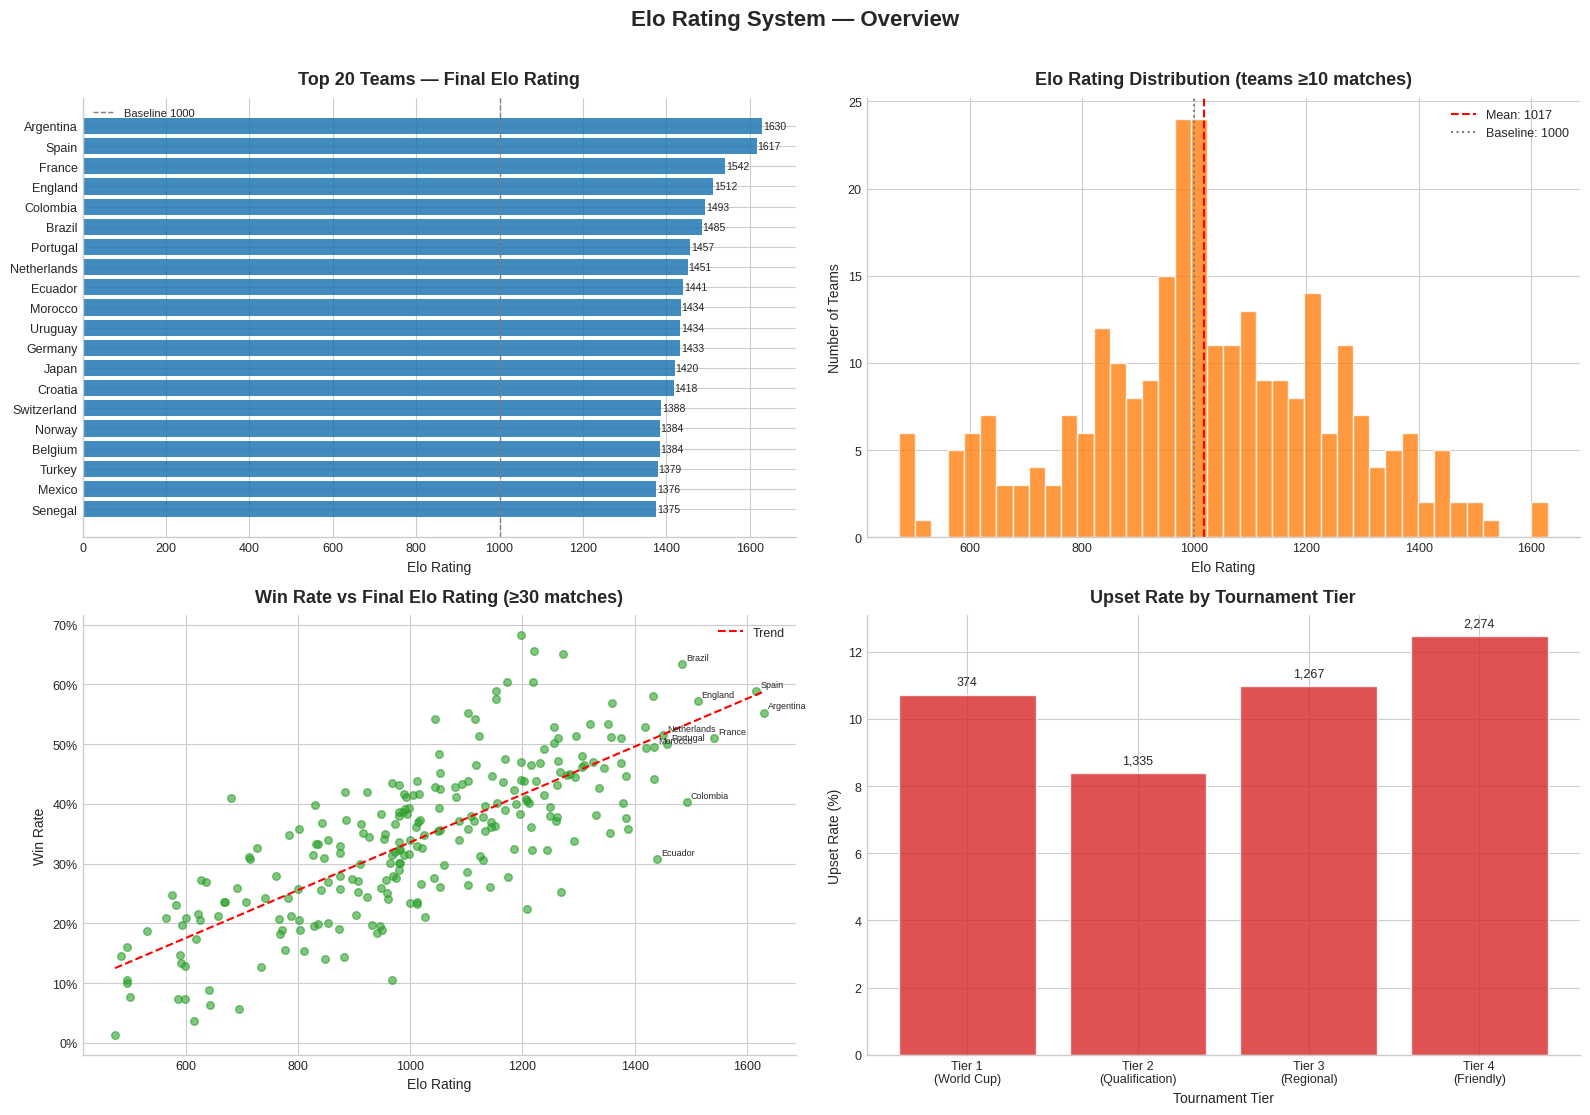

In [29]:
# FIG 1: TOP TEAMS OVERVIEW
fig1, axes = plt.subplots(2, 2, figsize=(16, 11))
fig1.suptitle("Elo Rating System — Overview", fontsize = 16,
              fontweight = "bold", y = 1.01)

# TOP 20 FINAL RATING
ax = axes[0, 0]
top20 = final_ratings.head(20).sort_values("elo_rating")
bars = ax.barh(top20["team"], top20["elo_rating"], color = COLORS[0], alpha = 0.85)
ax.axvline(1000, color = "gray", linestyle = "--", linewidth = 1, label = "Baseline 1000")
for bar, val in zip(bars, top20["elo_rating"]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}", va = "center", fontsize = 7.5)
style_ax(ax, "Top 20 Teams — Final Elo Rating", "Elo Rating")
ax.legend(fontsize = 8)


# ELO RATING DISTRIBUTION
ax = axes[0, 1]
# Only teams with ≥10 matches to exclude micro-nations
active = final_ratings[final_ratings["total_matches"] >= 10]["elo_rating"]
ax.hist(active, bins = 40, color = COLORS[1], alpha = 0.8, edgecolor = "white")
ax.axvline(active.mean(), color = "red", linestyle = "--", linewidth = 1.5,
           label = f"Mean: {active.mean():.0f}")
ax.axvline(1000, color = "gray", linestyle = ":", linewidth = 1.5, label = "Baseline: 1000")
style_ax(ax, "Elo Rating Distribution (teams ≥10 matches)",
         "Elo Rating", "Number of Teams")
ax.legend(fontsize = 9)


# WIN RATE VS ELO
ax = axes[1, 0]
plot_df = final_ratings[final_ratings["total_matches"] >= 30].dropna(subset = ["win_rate"])
scatter = ax.scatter(plot_df["elo_rating"], plot_df["win_rate"],
                     alpha = 0.6, s = 30, color = COLORS[2])
# LABEL THE TOP 10 BY ELO
for _, row in plot_df.nlargest(10, "elo_rating").iterrows():
    ax.annotate(row["team"], (row["elo_rating"], row["win_rate"]),
                fontsize = 6.5, xytext = (3, 3), textcoords = "offset points")
# TREND LINE
z = np.polyfit(plot_df["elo_rating"], plot_df["win_rate"], 1)
xr = np.linspace(plot_df["elo_rating"].min(), plot_df["elo_rating"].max(), 100)
ax.plot(xr, np.poly1d(z)(xr), "r--", linewidth = 1.5, label = "Trend")
style_ax(ax, "Win Rate vs Final Elo Rating (≥30 matches)",
         "Elo Rating", "Win Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=9)


# UPSET RATE BY TOURNAMENT TIER

ax = axes[1, 1]
tier_labels = {1: "Tier 1\n(World Cup)", 2: "Tier 2\n(Qualification)",
               3: "Tier 3\n(Regional)", 4: "Tier 4\n(Friendly)"}
upset_by_tier = (
    matches_elo.groupby("tournament_tier")["upset"]
    .agg(["sum", "count"])
    .assign(upset_rate = lambda x: x["sum"] / x["count"])
)
tiers  = [tier_labels.get(t, str(t)) for t in upset_by_tier.index]
rates  = upset_by_tier["upset_rate"].values
counts = upset_by_tier["sum"].values
bars   = ax.bar(tiers, rates * 100, color = COLORS[3], alpha = 0.8, edgecolor = "white")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{cnt:,}", ha = "center", fontsize = 9)
style_ax(ax, "Upset Rate by Tournament Tier", "Tournament Tier", "Upset Rate (%)")

fig1.tight_layout()
fig1.savefig("elo_fig1_overview.png", dpi = 150, bbox_inches = "tight")


Argentina leads the global Elo rankings with a rating of 1630, closely followed by Spain at 1617 and France at 1542, confirming these three nations as the strongest international sides based on their overall match history. What is interesting is that the top 20 includes some less traditional powerhouses like Morocco, Ecuador, and Japan, reflecting how much these nations have improved in recent years.

Looking at the distribution chart, most teams cluster around the 1000 baseline, which makes sense since the system is designed to be zero-sum. The mean sits at 1017, just slightly above baseline, and only a handful of elite teams push above 1400. The win rate versus Elo scatter shows a clear and logical pattern: the higher a team's Elo, the more matches they tend to win. Brazil stands out as a slight outlier, posting a win rate above 65% despite not topping the Elo table, suggesting they have been particularly dominant against weaker opponents.

Finally, friendly matches (Tier 4) produce the most upsets at around 12.5%, which makes intuitive sense since top teams often rotate squads and experiment in friendlies. World Cup matches surprisingly show a higher upset rate than qualification games, likely because the knockout format forces every top team to eventually face another top team.

## ELO HISTORY TIMELINE (TOP 8 NATIONS)

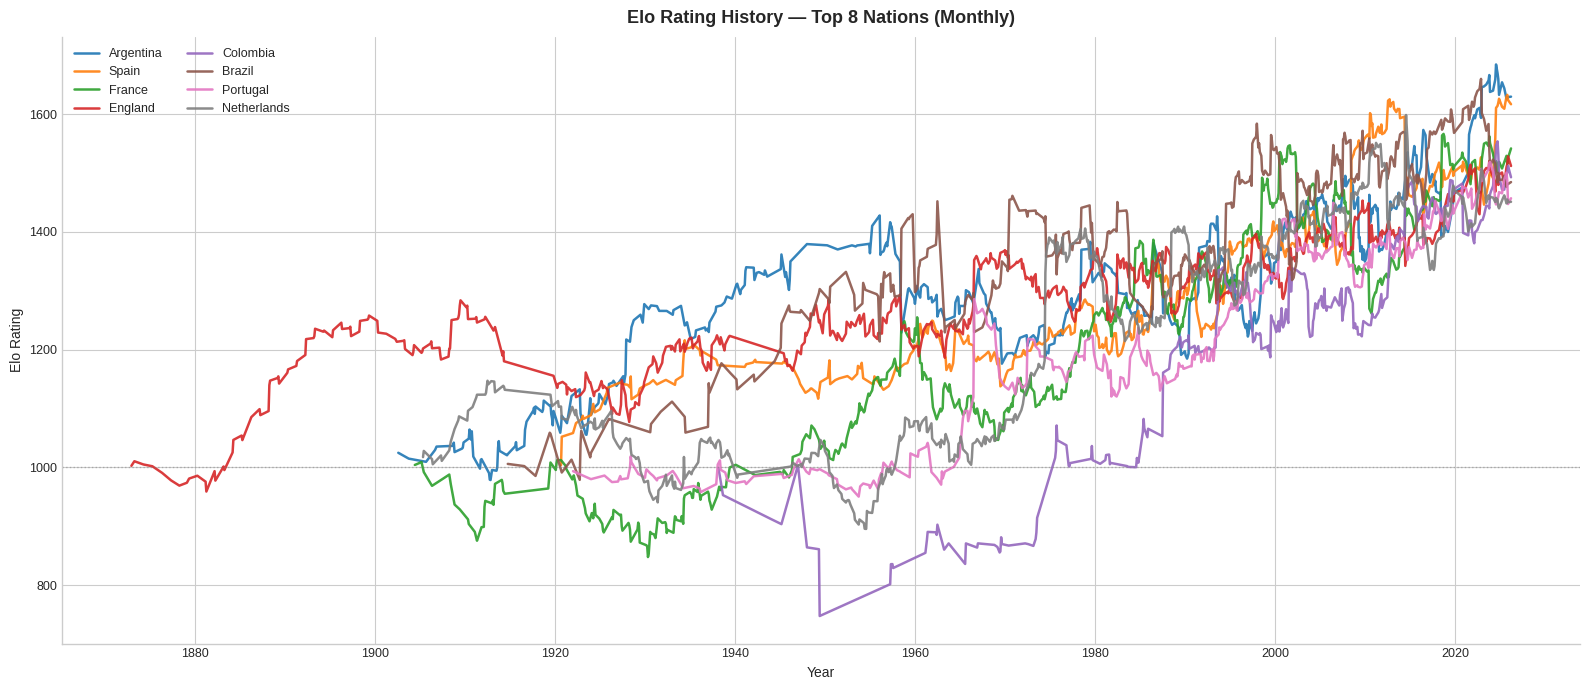

In [30]:
fig2, ax = plt.subplots(figsize = (16, 7))

top8_teams = final_ratings.head(8)["team"].tolist()

for i, team in enumerate(top8_teams):
    team_hist = (
        elo_history[elo_history["team"] == team]
        .set_index("date")["elo_rating"]
        .resample("ME")          # MONTH-END
        .last()
        .interpolate()
        .reset_index()
    )
    ax.plot(team_hist["date"], team_hist["elo_rating"],
            label = team, color = COLORS[i % len(COLORS)], linewidth = 1.8, alpha = 0.9)

ax.axhline(1000, color = "gray", linestyle = ":", linewidth = 1, alpha = 0.5)
style_ax(ax, "Elo Rating History — Top 8 Nations (Monthly)", "Year", "Elo Rating")
ax.legend(loc = "upper left", fontsize = 9, ncol = 2)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
fig2.tight_layout()
fig2.savefig("elo_fig2_history.png", dpi = 150, bbox_inches = "tight")

England stands out as the earliest dominant force in international football, carrying a notably high Elo rating through the late 1800s and early 1900s, which reflects their status as the founders of the modern game. However, their lead gradually eroded as more nations joined the international stage and began to compete seriously. Argentina emerged as a strong side from the early 1900s and has maintained a consistently high rating across the entire century, which explains why they sit at the top of the current rankings. Brazil's trajectory is particularly interesting as they started relatively modest but climbed sharply from the 1950s onward, coinciding with their World Cup dominance in that era. The most dramatic story in this chart belongs to Colombia, whose rating sat near the bottom for much of the 20th century before rocketing upward from around 2010, reflecting their golden generation led by players like James Rodriguez and Falcao. France and Portugal both show steep rises from the mid-1990s onward, aligning perfectly with France's 1998 World Cup win and Portugal's rise with Cristiano Ronaldo's generation. The general upward drift visible across all teams from 2000 onwards is also worth noting, likely because all these top nations are simply playing more high-stakes matches against each other, pushing their ratings higher collectively.

# MATCH-LEVEL ANALYTICS

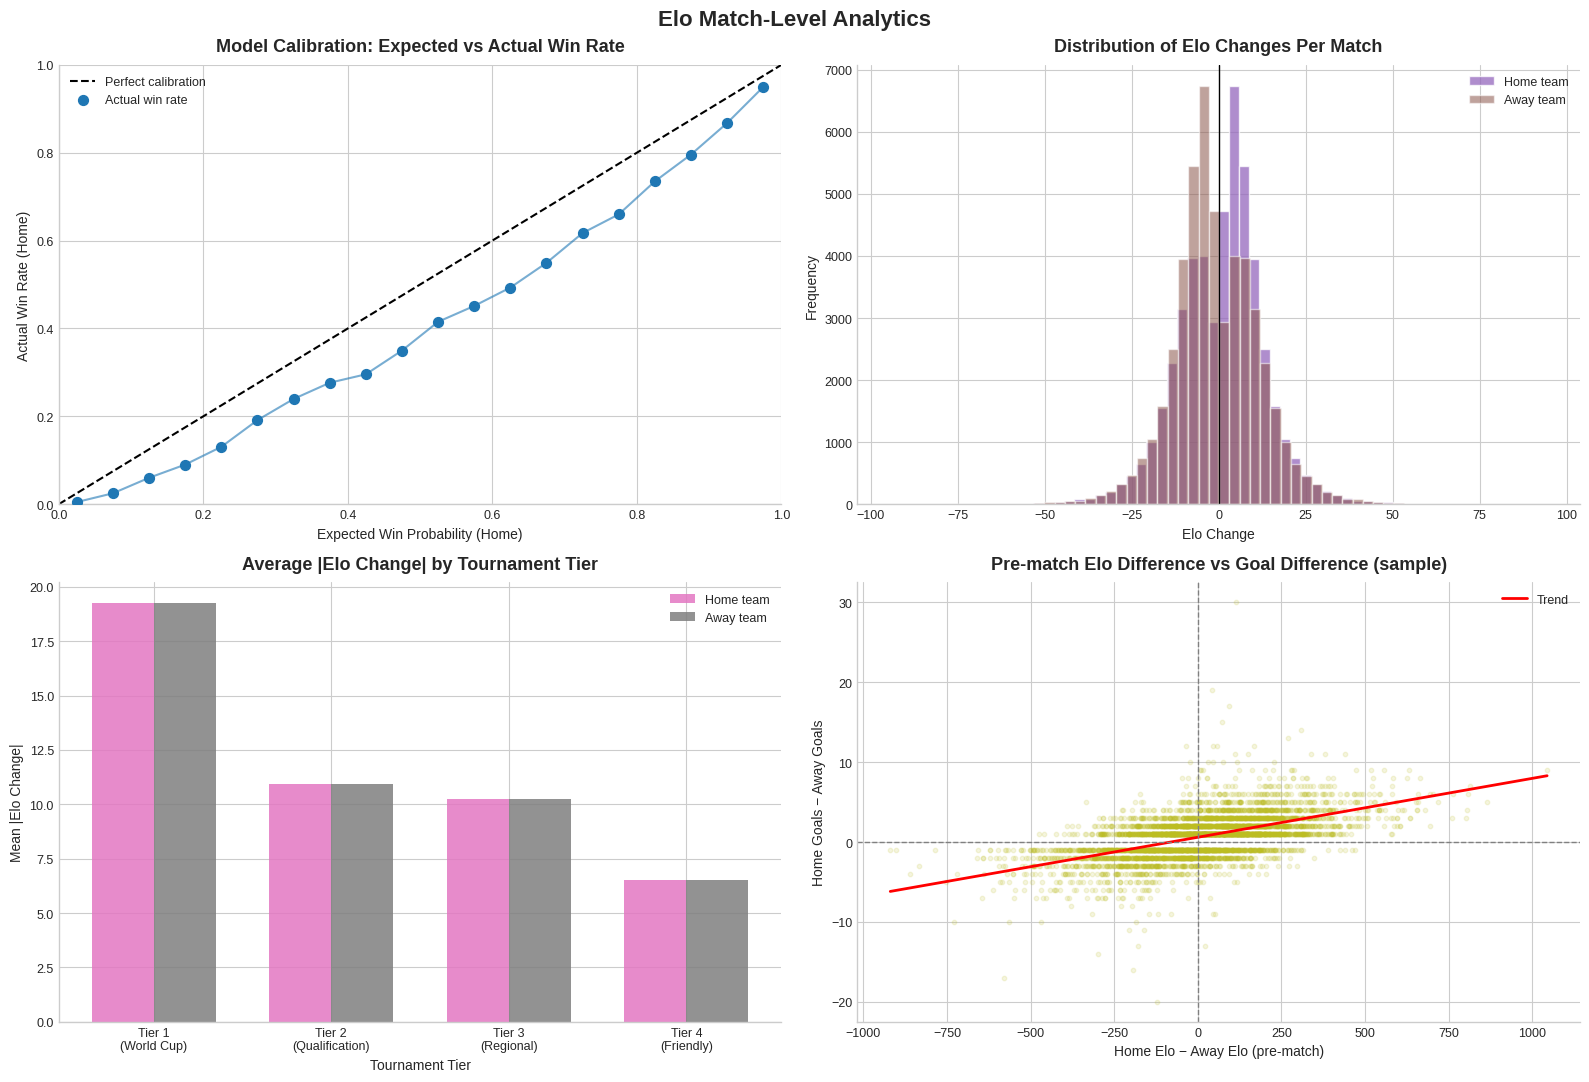

In [34]:
fig3, axes = plt.subplots(2, 2, figsize = (16, 11))
fig3.suptitle("Elo Match-Level Analytics", fontsize = 16, fontweight = "bold")

# EXPECTED PROBABILITY VS ACTUAL OUTCOME
ax = axes[0, 0]
bins = np.arange(0, 1.05, 0.05)
bin_mid = (bins[:-1] + bins[1:]) / 2

matches_elo["prob_bin"] = pd.cut(matches_elo["exp_home_win_prob"],
                                 bins = bins, labels = bin_mid)

cal = matches_elo.groupby("prob_bin", observed = True).apply(
    lambda g: (g["result"] == "home_win").mean()
).reset_index(name = "actual_win_rate")

cal["prob_bin"] = cal["prob_bin"].astype(float)

ax.plot([0, 1], [0, 1], "k--", linewidth = 1.5, label = "Perfect calibration")
ax.scatter(cal["prob_bin"], cal["actual_win_rate"], color = COLORS[0],
           s = 50, zorder = 5, label = "Actual win rate")

ax.plot(cal["prob_bin"], cal["actual_win_rate"], color = COLORS[0], alpha = 0.6)
style_ax(ax, "Model Calibration: Expected vs Actual Win Rate",
         "Expected Win Probability (Home)", "Actual Win Rate (Home)")

ax.legend(fontsize = 9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ELO CHANGE DISTRIBUTION

ax = axes[0, 1]
ax.hist(matches_elo["home_elo_change"], bins = 60, color = COLORS[4],
        alpha = 0.75, edgecolor = "white", label = "Home team")
ax.hist(matches_elo["away_elo_change"], bins = 60, color = COLORS[5],
        alpha = 0.55, edgecolor = "white", label = "Away team")
ax.axvline(0, color = "black", linewidth = 1)
style_ax(ax, "Distribution of Elo Changes Per Match",
         "Elo Change", "Frequency")
ax.legend(fontsize = 9)

# AVERAGE ELO CHANGE BY TIER

ax = axes[1, 0]
tier_change = (
    matches_elo.groupby("tournament_tier")[["home_elo_change","away_elo_change"]]
    .apply(lambda g: g.abs().mean())
    .reset_index()
)
x = np.arange(len(tier_change))
w = 0.35
ax.bar(x - w/2, tier_change["home_elo_change"], w, label = "Home team",
       color = COLORS[6], alpha = 0.85)
ax.bar(x + w/2, tier_change["away_elo_change"], w, label = "Away team",
       color = COLORS[7], alpha = 0.85)

ax.set_xticks(x)
ax.set_xticklabels([tier_labels.get(t,"T"+str(t)) for t in tier_change["tournament_tier"]], fontsize = 9)
style_ax(ax, "Average |Elo Change| by Tournament Tier",
         "Tournament Tier", "Mean |Elo Change|")
ax.legend(fontsize=9)

# RATING GAP VS GOAL DIFFERENCE
ax = axes[1, 1]
sample = matches_elo[matches_elo["result"] != "draw"].sample(min(5000, len(matches_elo)), random_state = 42)
ax.scatter(sample["elo_diff"], sample["home_score"] - sample["away_score"],
           alpha = 0.15, s = 10, color = COLORS[8])
# TREND
z = np.polyfit(sample["elo_diff"], sample["home_score"] - sample["away_score"], 1)
xr = np.linspace(sample["elo_diff"].min(), sample["elo_diff"].max(), 100)
ax.plot(xr, np.poly1d(z)(xr), "r-", linewidth = 2, label = "Trend")
ax.axhline(0, color = "gray", linestyle = "--", linewidth = 1)
ax.axvline(0, color = "gray", linestyle = "--", linewidth = 1)
style_ax(ax, "Pre-match Elo Difference vs Goal Difference (sample)",
         "Home Elo − Away Elo (pre-match)", "Home Goals − Away Goals")
ax.legend(fontsize = 9)

fig3.tight_layout()
fig3.savefig("elo_fig3_match_analytics.png", dpi = 150, bbox_inches = "tight")


The calibration chart in the top left is a health check for the entire Elo model, and it passes with good marks. The actual win rates follow the expected probabilities quite closely, meaning when the model says a team has a 70% chance of winning, they actually win roughly that often. The slight underestimation at higher probabilities suggests the model is a touch conservative when heavy favourites are involved, but overall the system is reliable. The Elo change distribution shows that most matches only shift a team's rating by somewhere between minus 25 and plus 25 points, which is expected since small, incremental updates keep the system stable over time. The home and away distributions are nearly identical, confirming the model treats both sides symmetrically after accounting for home advantage. The tournament tier chart delivers a very intuitive finding: World Cup matches move ratings the most, nearly 20 points on average per match, while friendly games barely move the needle at around 6 points. This is by design since higher K-factors are assigned to more important tournaments, meaning a World Cup result carries roughly three times the weight of a friendly. Finally, the bottom right scatter plot shows a gentle but clear positive trend: teams with a higher pre-match Elo rating tend to win by more goals. The relationship is noisy, as football always is, but the direction is consistent and confirms that Elo ratings carry real predictive signal about match outcomes.

# DECADE BY DECADE DOMINANCE

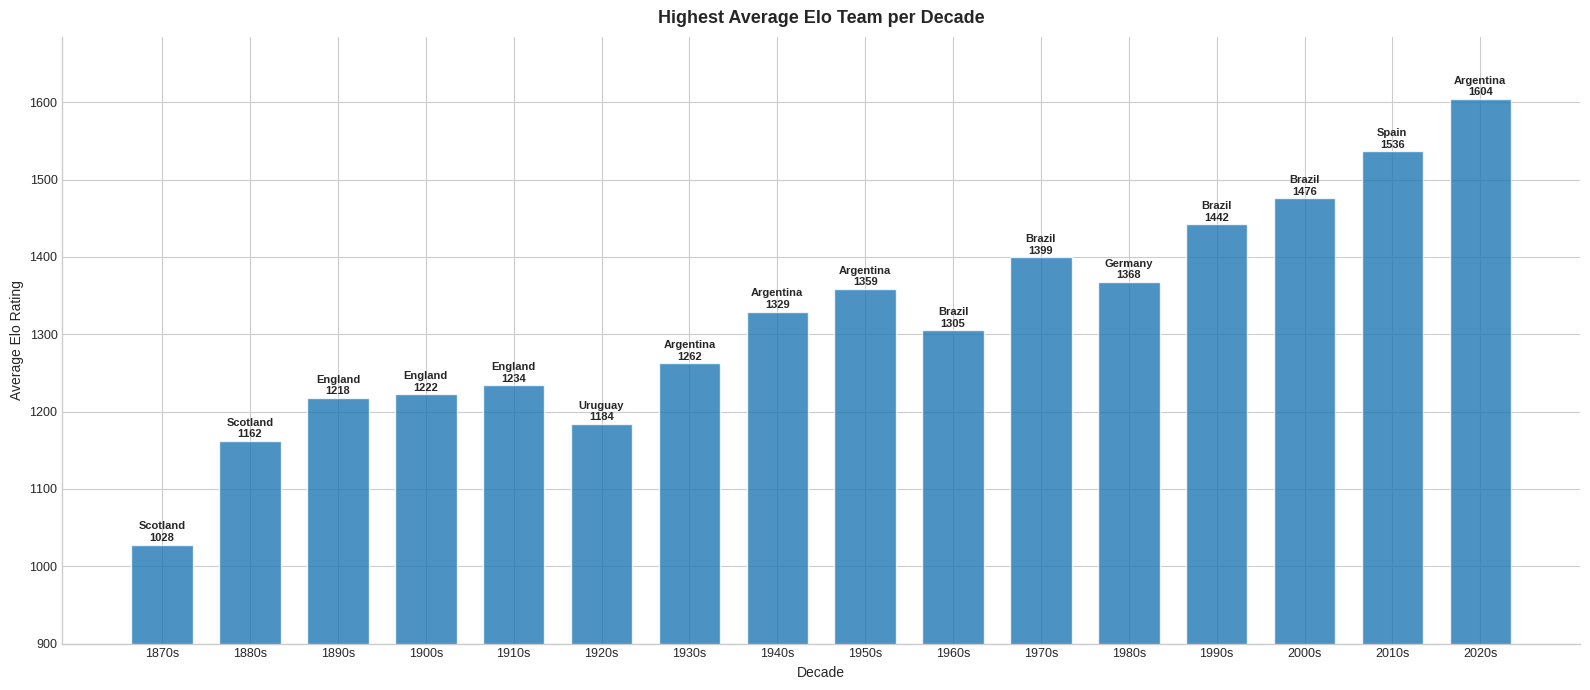

In [33]:
fig4, ax = plt.subplots(figsize=(16, 7))


matches_elo["decade"] = (matches_elo["date"].dt.year // 10) * 10

decade_home = matches_elo[["decade", "home_team","home_elo_post"]].rename(
    columns = {"home_team": "team", "home_elo_post": "elo"})

decade_away = matches_elo[["decade", "away_team", "away_elo_post"]].rename(
    columns = {"away_team": "team","away_elo_post": "elo"})
decade_all  = pd.concat([decade_home, decade_away])

top_per_decade = (
    decade_all.groupby(["decade","team"])["elo"]
    .mean()
    .reset_index()
    .sort_values(["decade","elo"], ascending = [True,False])
    .groupby("decade")
    .head(1)   # top team per decade
    .reset_index(drop=True)
)

decades = top_per_decade["decade"]
elos    = top_per_decade["elo"]
teams   = top_per_decade["team"]

bars = ax.bar(decades, elos, width = 7, color = COLORS[0],
              alpha = 0.8, edgecolor = "white")

for bar, team, elo in zip(bars, teams, elos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{team}\n{elo:.0f}", ha = "center", va = "bottom",
            fontsize = 8, fontweight = "bold")

style_ax(ax, "Highest Average Elo Team per Decade", "Decade", "Average Elo Rating")
ax.set_xticks(decades)
ax.set_xticklabels([f"{d}s" for d in decades], fontsize=9)
ax.set_ylim(bottom = 900)

fig4.tight_layout()
fig4.savefig("elo_fig4_decade_dominance.png", dpi = 150, bbox_inches = "tight")

This chart tells the story of international football's shifting power over 150 years in a single glance. Scotland and England traded dominance in the earliest decades, which is reasonable given that they were among the very first nations to play organised international football and had few competitors at the time. England held the top spot through the 1890s to 1910s before Uruguay briefly claimed it in the 1920s, a reminder that South America was rapidly catching up with Europe. From the 1930s onward, Argentina took firm control and dominated four separate decades, making them arguably the most consistently excellent nation in football history when viewed through this lens. Brazil interrupted that run by owning the 1960s, 1970s, 1990s, and 2000s, which aligns perfectly with their five World Cup victories and generations of world class talent. Germany's solitary appearance at the top in the 1980s reflects their ruthless efficiency during that era, reaching three consecutive World Cup finals. The most striking observation is the steady rise in the actual Elo values decade by decade, climbing from around 1028 in the 1870s all the way to 1604 in the 2020s. This reflects the growing competitiveness of international football globally, as the top teams are now playing more frequently against stronger opposition, naturally pushing elite ratings higher. Argentina's current 2020s dominance with a rating of 1604 is the highest any team has ever averaged across a full decade, cementing their status as the greatest team of the modern era.